In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("amp_dataset-revisado.csv", on_bad_lines='skip')

# Aminos Alfa-Helices: A, L, M, E, Q
#Aminos Beta-Folha: V, I, Y, F, W
# "Cotovelos": P, G

#Apolar: A, V, L, E, Q I, L, M, F, Y, W
#Polar: K, R, H, D, E, S, T, N, Q

#Exemplo Alfa-Hélice perfeita: AAAAAAA...
#Alfa-Helice anfipática: LKLKLKLK...
#Folha-Beta anfipática: VKVKVKVK...

apolar = {'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G'} 
polar = {'S', 'T', 'C', 'Y', 'N', 'Q', 'D', 'E', 'K', 'R', 'H'}

def calcular_pontuacao_anfipatica(sequencia):
    sequencia = sequencia.upper()

    pontuacao_total = 0.0
    length = len(sequencia)
    indices_apolares = [i for i, aminoacido in enumerate(sequencia) if aminoacido in apolar]
    
    if len(indices_apolares) < 2:
        return float(len(sequencia))
        
    diferenca = []
    
    for i in range(len(indices_apolares)-1): 
        if(i<len(indices_apolares)):
            diferenca.append(indices_apolares[i] - indices_apolares[i+1])

    pontuacao_total = sum(diferenca)/length
    return pontuacao_total
   

#=============================================

# Definição dos conjuntos de aminoácidos (corrigidos)

#

def calcular_pontuacao_anfipatica_feito(sequencia):
    sequencia = sequencia.upper()
    if len(sequencia) < 3:
        return 0

    pontuacao_total = 0.0
    pesos = [0.3, 0.5, 0.3]
    
    padrao_ideal_1 = ['polar', 'apolar','polar']
    padrao_ideal_2 = ['apolar','polar', 'apolar']

    for i in range(len(sequencia) - 2):
        tripeptideo = sequencia[i : i+3]
        
        padrao_atual = []
        for aminoacido in tripeptideo:
            if aminoacido in apolar:
                padrao_atual.append('apolar')
            elif aminoacido in polar:
                padrao_atual.append('polar')
            else:
                padrao_atual.append('neutro')

        pontuacao_match_1 = 0
        pontuacao_match_2 = 0
        
        for j in range(3):
            if padrao_atual[j] == padrao_ideal_1[j]:
                pontuacao_match_1 += pesos[j]
            if padrao_atual[j] == padrao_ideal_2[j]:
                pontuacao_match_2 += pesos[j]
        
        # Adiciona a maior das duas pontuações à pontuação total
        pontuacao_total += max(pontuacao_match_1, pontuacao_match_2)

    # Normaliza a pontuação pelo número de tripeptídeos analisados
    numero_de_tripeptideos = len(sequencia) - 2
    pontuacao_final_normalizada = pontuacao_total / numero_de_tripeptideos
    
    return pontuacao_final_normalizada

# --- Exemplo de Uso ---
peptideo_anfipatico_ideal = "LKLKLKLKLK"  # Padrão alternado perfeito
peptideo_agrupado = "LLLLLKKKKK"   # Sem alternância
peptideo_aleatorio = "AGKPYEWQSFL"



#=============================================



amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
def aa_composition(seq):
    seq = seq.upper()
    length = len(seq)
    comp = {}
    for aa in amino_acids:
        comp[aa] = seq.count(aa) / length
    return comp
    

features_acc = df['sequence'].apply(aa_composition)
feature_anfipatico = df['sequence'].apply(calcular_pontuacao_anfipatica)
#feature_anf_feito = df['sequence'].apply(calcular_pontuacao_anfipatica_feito)


features_df = pd.DataFrame(features_acc.tolist(), index=df.index)

features_df['pontuacao_anfipatica'] = feature_anfipatico
#features_df['pontuacao_anf_feito'] = feature_anf_feito

features_df['label'] = df['class'].map({'AMP': 1, 'nonAMP': 0})

X = features_df.drop(columns=['label'])
y = features_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# treinar ============================================

model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("--- Importância das Features ---")
print(feature_importances) 

# scale = range(1,400,50)
# acuracia_model = []
# for i in scale:
#     model = RandomForestClassifier(n_estimators=i, random_state=42, class_weight="balanced")
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acuracia_model.append(accuracy_score(y_test, y_pred))


#model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced") -  0.8984947896565033
#model = DecisionTreeClassifier(max_depth=10, random_state=42) - 0.8433037437282902
#model = KNeighborsClassifier(n_neighbors=4) -  0.8708992666923968

feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# plt.scatter(scale,acuracia_model)
# print(acuracia_model)



Acurácia: 0.9008629339755168
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3413
           1       0.89      0.79      0.83      1570

    accuracy                           0.90      4983
   macro avg       0.90      0.87      0.88      4983
weighted avg       0.90      0.90      0.90      4983

--- Importância das Features ---
                 feature  importance
10                     M    0.126015
8                      K    0.085638
1                      C    0.084479
20  pontuacao_anfipatica    0.068899
14                     R    0.056363
2                      D    0.054416
12                     P    0.051759
5                      G    0.045990
9                      L    0.043550
3                      E    0.038797
19                     Y    0.037698
16                     T    0.034308
4                      F    0.033788
13                     Q    0.033598
7                      I    0.033568
15                 

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# carregar dataset
df = pd.read_csv("amp_dataset-revisado.csv", on_bad_lines='skip')

# listas de aminoácidos
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
positive = set("KR")
negative = set("DE")
hydrophobic = set("AILMFWYV")

# escala de hidrofobicidade Kyte-Doolittle (simplificada)
hydro_scale = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
    'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
    'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

# função AAC
def aa_composition(seq):
    seq = seq.upper()
    length = len(seq)
    comp = {}
    for aa in amino_acids:
        comp[aa] = seq.count(aa) / length
    return comp

# função para extrair features físico-químicas
def peptide_features(seq):
    seq = seq.upper()
    length = len(seq)
    feat = {}
    charge = sum(1 for aa in seq if aa in positive) - sum(1 for aa in seq if aa in negative)
    feat["charge"] = charge
    feat["frac_positive"] = sum(1 for aa in seq if aa in positive) / length
    feat["frac_negative"] = sum(1 for aa in seq if aa in negative) / length
    feat["frac_hydrophobic"] = sum(1 for aa in seq if aa in hydrophobic) / length
    feat["length"] = length
    feat["hydro_mean"] = sum(hydro_scale.get(aa, 0) for aa in seq) / length
    return feat

# gerar features
#aac_features = df['sequence'].apply(aa_composition)
physchem_features = df['sequence'].apply(peptide_features)

# juntar tudo em um único DataFrame
#features_df = pd.concat([pd.DataFrame(aac_features.tolist()),
                        # pd.DataFrame(physchem_features.tolist())], axis=1)

features_df = pd.DataFrame(physchem_features.tolist())

# adicionar rótulo
features_df['label'] = df['class'].map({'AMP': 1, 'nonAMP': 0})

# separar X e y
X = features_df.drop(columns=['label'])
y = features_df['label']

# dividir em treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# modelo KNN (pode trocar para RandomForest ou DecisionTree)
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
#model = DecisionTreeClassifier(max_depth=4, random_state=42)
#model = KNeighborsClassifier(n_neighbors=14)
model.fit(X_train, y_train)
print(len(X_train))

# prever
y_pred = model.predict(X_test)

# avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


11627
Acurácia: 0.8711619506321493
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      3483
           1       0.80      0.76      0.78      1500

    accuracy                           0.87      4983
   macro avg       0.85      0.84      0.84      4983
weighted avg       0.87      0.87      0.87      4983



In [43]:



from Bio import SeqIO
import pandas as pd

def fasta_para_tabela(fasta_path, csv_out_path):
    """
    Lê um arquivo FASTA e salva em CSV uma tabela com:
    - id (header)
    - description (texto depois do id no header)
    - sequence (a sequência de aminoácidos)
    - length (comprimento da sequência)
    """
    dados = []
    for record in SeqIO.parse(fasta_path, "fasta"):
        # record.id → parte do header até primeiro espaço
        # record.description → o header completo (id + descrição)
        seq = str(record.seq)
        dados.append({
            "id": record.id,
            "description": record.description,
            "sequence": seq,
            "length": len(seq)
        })
    
    df = pd.DataFrame(dados)
    # opcional: filtrar sequências com caracteres inválidos
    # df = df[~df["sequence"].str.contains("[XBZJ]")]  # X, B, Z ou J, dependendo do que você achar inválido

    df.to_csv(csv_out_path, index=False)
    print(f"Tabela salva em {csv_out_path}, com {len(df)} sequências.")

if __name__ == "__main__":
    fasta_input = "uniprotkb_reviewed_true_NOT_antimicrobi_2025_09_26.fasta"   # Substitua pelo nome do seu arquivo FASTA
    csv_output = "non_amp_sequences_table.csv"
    fasta_para_tabela(fasta_input, csv_output)



Tabela salva em non_amp_sequences_table.csv, com 567701 sequências.


Tamanho do dataset: 16610
Distribuição das classes:
class
nonAMP    11432
AMP        5178
Name: count, dtype: int64
Valores faltantes: 0
Gerando features AAC...
Gerando features físico-químicas...
Dimensões finais do dataset: (16610, 26)
Features utilizadas: 25

=== RANDOM FOREST ===
Acurácia: 0.9057
AUC-ROC: 0.9621

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3430
           1       0.85      0.85      0.85      1553

    accuracy                           0.91      4983
   macro avg       0.89      0.89      0.89      4983
weighted avg       0.91      0.91      0.91      4983


=== VALIDAÇÃO CRUZADA ===
AUC-ROC médio (CV): 0.9635 ± 0.0033

=== TOP 10 FEATURES MAIS IMPORTANTES ===
              feature  importance
20             length    0.139703
10                  M    0.138896
1                   C    0.076713
8                   K    0.065752
22     positive_ratio    0.061311
23     negative_r

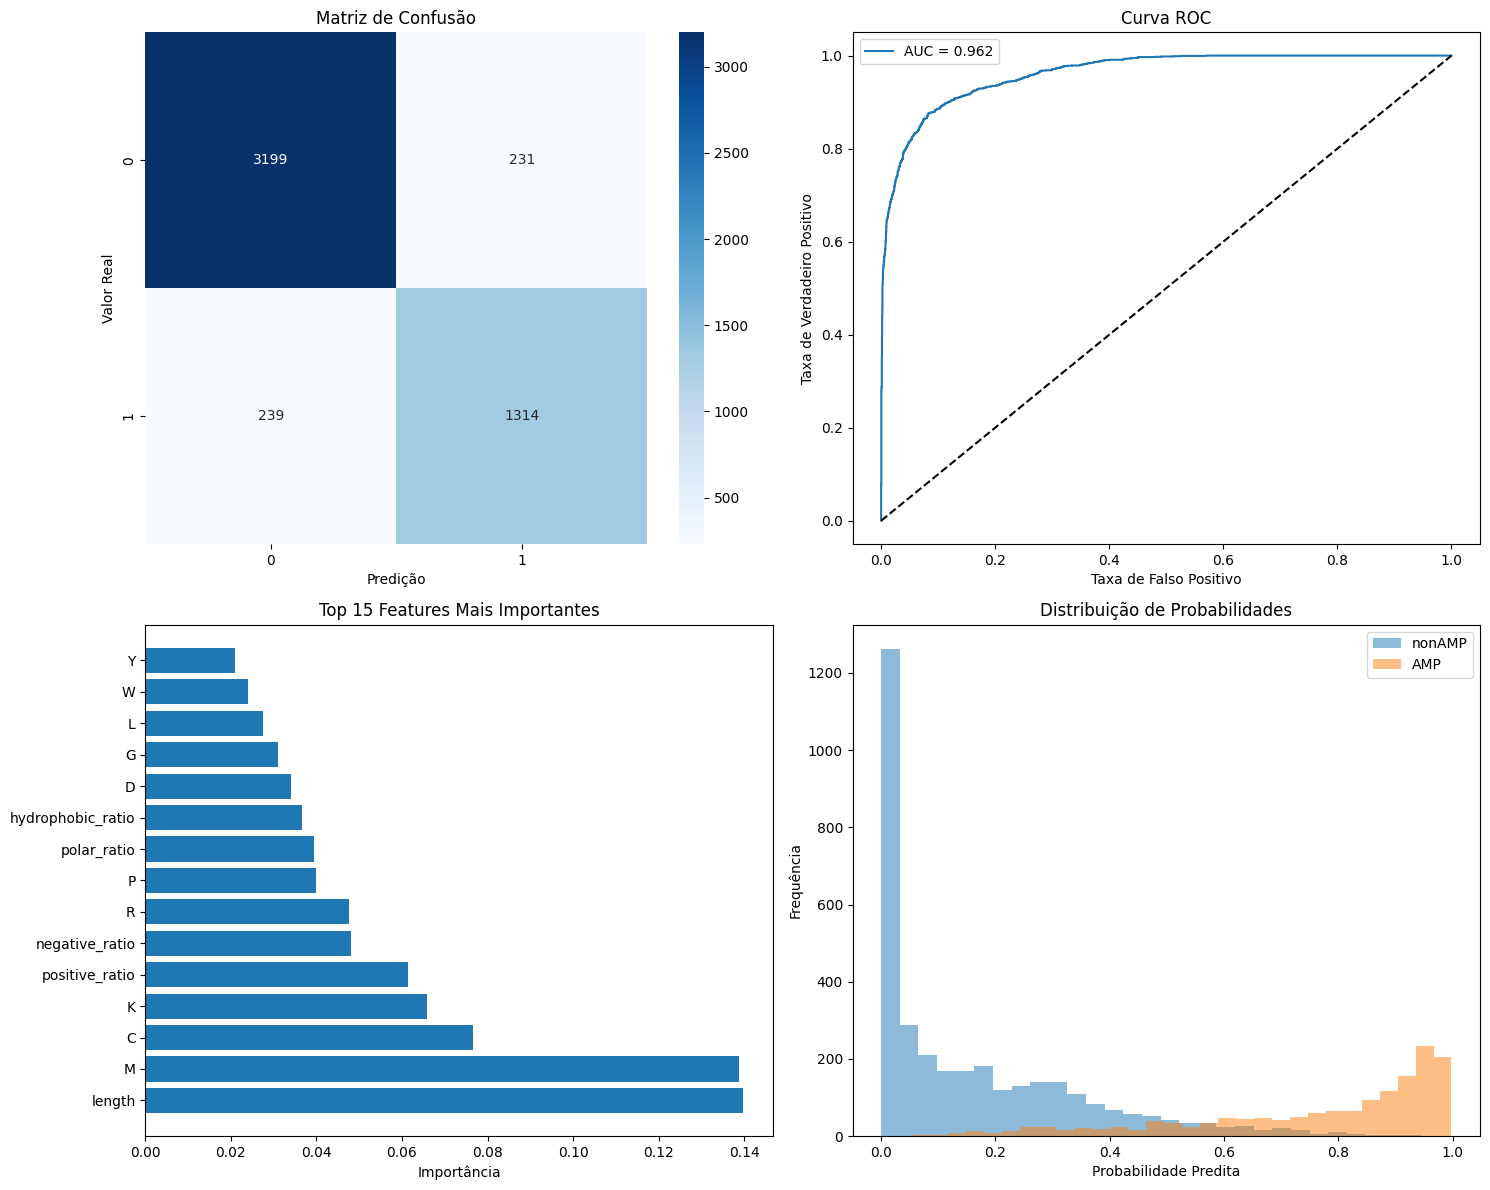


=== ANÁLISE DE AMINOÁCIDOS ===
Aminoácidos mais importantes para classificação:
   feature  importance
10       M    0.138896
1        C    0.076713
8        K    0.065752
14       R    0.047546
12       P    0.039888
2        D    0.034043
5        G    0.030997
9        L    0.027426
18       W    0.024018
19       Y    0.021008

=== ESTATÍSTICAS POR CLASSE ===
         length                                                      \
          count       mean        std  min   25%   50%   75%    max   
class                                                                 
AMP      5178.0  34.133256  20.608730  2.0  19.0  29.0  45.0  101.0   
nonAMP  11432.0  30.877187  13.127123  2.0  19.0  35.0  42.0   50.0   

       hydrophobic_ratio            ... negative_ratio        polar_ratio  \
                   count      mean  ...            75%    max       count   
class                               ...                                     
AMP               5178.0  0.438619  ...       

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset
df = pd.read_csv("amp_dataset-OK.csv")

# Validação básica dos dados
print(f"Tamanho do dataset: {len(df)}")
print(f"Distribuição das classes:\n{df['class'].value_counts()}")
print(f"Valores faltantes: {df.isnull().sum().sum()}")

# Lista de aminoácidos padrão
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(seq):
    """Calcula composição de aminoácidos"""
    seq = seq.upper()
    # Remove caracteres não-aminoácidos
    seq = ''.join([aa for aa in seq if aa in amino_acids])
    length = len(seq)
    
    if length == 0:
        return {aa: 0 for aa in amino_acids}
    
    comp = {}
    for aa in amino_acids:
        comp[aa] = seq.count(aa) / length
    return comp

def calculate_physicochemical_properties(seq):
    """Calcula propriedades físico-químicas básicas"""
    seq = seq.upper()
    seq = ''.join([aa for aa in seq if aa in amino_acids])
    
    if len(seq) == 0:
        return {'length': 0, 'hydrophobic_ratio': 0, 'positive_ratio': 0, 
                'negative_ratio': 0, 'polar_ratio': 0}
    
    # Grupos de aminoácidos
    hydrophobic = set('AILMFPWYV')
    positive = set('RK')  # Básicos
    negative = set('DE')  # Ácidos
    polar = set('NQSTY')
    
    properties = {
        'length': len(seq),
        'hydrophobic_ratio': sum(1 for aa in seq if aa in hydrophobic) / len(seq),
        'positive_ratio': sum(1 for aa in seq if aa in positive) / len(seq),
        'negative_ratio': sum(1 for aa in seq if aa in negative) / len(seq),
        'polar_ratio': sum(1 for aa in seq if aa in polar) / len(seq)
    }
    
    return properties

# Gerar features AAC
print("Gerando features AAC...")
features_aac = df['sequence'].apply(aa_composition)
features_aac_df = pd.DataFrame(features_aac.tolist())

# Gerar features físico-químicas
print("Gerando features físico-químicas...")
features_physchem = df['sequence'].apply(calculate_physicochemical_properties)
features_physchem_df = pd.DataFrame(features_physchem.tolist())

# Combinar todas as features
features_df = pd.concat([features_aac_df, features_physchem_df], axis=1)

# Adicionar rótulos
features_df['label'] = df['class'].map({'AMP': 1, 'nonAMP': 0})

# Remover possíveis NaN
features_df = features_df.dropna()

print(f"Dimensões finais do dataset: {features_df.shape}")
print(f"Features utilizadas: {features_df.shape[1] - 1}")

# Separar X (features) e y (target)
X = features_df.drop(columns=['label'])
y = features_df['label']

# Dividir em treino/teste com stratify para manter proporção
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Opcional: normalizar features (útil para alguns algoritmos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo Random Forest
print("\n=== RANDOM FOREST ===")
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    class_weight="balanced",
    max_depth=15,  # Evita overfitting
    min_samples_split=10,
    min_samples_leaf=5
)

# Treinamento
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Avaliação
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_rf))

# Validação cruzada
print("\n=== VALIDAÇÃO CRUZADA ===")
cv_scores = cross_val_score(
    rf_model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f"AUC-ROC médio (CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Análise de importância das features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== TOP 10 FEATURES MAIS IMPORTANTES ===")
print(feature_importance.head(10))

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusão')
axes[0,0].set_ylabel('Valor Real')
axes[0,0].set_xlabel('Predição')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
auc = roc_auc_score(y_test, y_pred_proba_rf)
axes[0,1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0,1].plot([0, 1], [0, 1], 'k--')
axes[0,1].set_xlabel('Taxa de Falso Positivo')
axes[0,1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0,1].set_title('Curva ROC')
axes[0,1].legend()

# 3. Importância das features (top 15)
top_features = feature_importance.head(15)
axes[1,0].barh(range(len(top_features)), top_features['importance'])
axes[1,0].set_yticks(range(len(top_features)))
axes[1,0].set_yticklabels(top_features['feature'])
axes[1,0].set_xlabel('Importância')
axes[1,0].set_title('Top 15 Features Mais Importantes')

# 4. Distribuição de probabilidades
axes[1,1].hist(y_pred_proba_rf[y_test == 0], alpha=0.5, label='nonAMP', bins=30)
axes[1,1].hist(y_pred_proba_rf[y_test == 1], alpha=0.5, label='AMP', bins=30)
axes[1,1].set_xlabel('Probabilidade Predita')
axes[1,1].set_ylabel('Frequência')
axes[1,1].set_title('Distribuição de Probabilidades')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Análise de aminoácidos importantes para AMPs
print("\n=== ANÁLISE DE AMINOÁCIDOS ===")
aac_importance = feature_importance[feature_importance['feature'].isin(amino_acids)].head(10)
print("Aminoácidos mais importantes para classificação:")
print(aac_importance)

# Estatísticas descritivas por classe
print("\n=== ESTATÍSTICAS POR CLASSE ===")
df_with_features = df.copy()
physchem_features = df['sequence'].apply(calculate_physicochemical_properties)
physchem_df = pd.DataFrame(physchem_features.tolist())

for col in physchem_df.columns:
    df_with_features[col] = physchem_df[col]

stats_by_class = df_with_features.groupby('class')[['length', 'hydrophobic_ratio', 
                                                   'positive_ratio', 'negative_ratio', 
                                                   'polar_ratio']].describe()
print(stats_by_class)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Passo 1: Dados de Exemplo ---
# Criando um DataFrame que simula o seu arquivo.

df = pd.read_csv("amp_dataset-revisado.csv", on_bad_lines='skip')

# Exemplo de como renomear colunas, se necessário
df.rename(columns={'class': 'label'}, inplace=True)
# Insira este código logo após carregar seu DataFrame com pd.read_csv()

# Define o conjunto de todos os caracteres válidos (os 20 aminoácidos padrão)
amino_acids_validos = set("ACDEFGHIKLMNPQRSTVWY")

problematicas = []

# Itera sobre cada linha do seu DataFrame (index e a linha em si)
for index, row in df.iterrows():
    sequencia = row['sequence'].upper() # Pega a sequência e garante que está em maiúscula
    
    # Cria um conjunto com todos os caracteres únicos da sequência
    caracteres_na_sequencia = set(sequencia)
    
    # Verifica se há algum caractere na sequência que NÃO ESTÁ na nossa lista de válidos
    if not caracteres_na_sequencia.issubset(amino_acids_validos):
        # Encontra exatamente quais caracteres são os inválidos
        invalidos = caracteres_na_sequencia - amino_acids_validos
        print(f"ERRO: Sequência na linha {index} contém caracteres inválidos: {list(invalidos)}")
        print(f"   -> Sequência: {sequencia}\n")
        problematicas.append(index)

# No final, se você quiser, pode remover as linhas problemáticas para rodar o modelo
# df_limpo = df.drop(problematicas)
# print(f"{len(problematicas)} linhas problemáticas foram identificadas.")


# --- Passo 2: Engenharia de Features (Calculando do Zero) ---

# Dicionários de constantes que usaremos. Eles são a base do nosso conhecimento bioquímico.

# Escala de Hidrofobicidade de Kyte-Doolittle: Valores mais altos = mais hidrofóbico
HYDROPHOBICITY_SCALE = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8, 'G': -0.4, 'H': -3.2,
    'I': 4.5, 'K': -3.9, 'L': 3.8, 'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5,
    'R': -4.5, 'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

# pKa dos grupos ionizáveis dos aminoácidos e dos terminus da cadeia.
PKA_VALUES = {
    'K': 10.5, 'R': 12.5, 'H': 6.0,  # Básicos (ganham H+ para ficarem positivos)
    'D': 3.9,  'E': 4.3,  'C': 8.3,  'Y': 10.1, # Ácidos (perdem H+ para ficarem negativos)
    'N_terminus': 9.6, # pKa do grupo amino terminal
    'C_terminus': 2.4  # pKa do grupo carboxila terminal
}

# Pesos para o cálculo do Índice de Instabilidade (Guruprasad et al., 1990)
INSTABILITY_WEIGHTS = {
    'A': {'A': 42, 'L': -1, 'R': 17, 'K': 17, 'N': -23, 'M': 67, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 32, 'S': 4, 'E': 55, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'L': {'A': -1, 'L': -1, 'R': -1, 'K': -1, 'N': -1, 'M': -1, 'D': -1, 'F': -1, 'C': -1, 'P': -1, 'Q': -1, 'S': -1, 'E': -1, 'T': -1, 'G': -1, 'W': -1, 'H': -1, 'Y': -1, 'I': 9, 'V': -1},
    'R': {'A': 17, 'L': -1, 'R': 17, 'K': 17, 'N': -23, 'M': 17, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 32, 'S': 4, 'E': 17, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'K': {'A': 17, 'L': -1, 'R': 17, 'K': 17, 'N': -23, 'M': 17, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 32, 'S': 4, 'E': 17, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'N': {'A': -23, 'L': -1, 'R': -23, 'K': -23, 'N': -23, 'M': -23, 'D': -23, 'F': -23, 'C': -23, 'P': -23, 'Q': -23, 'S': -23, 'E': -23, 'T': -23, 'G': -23, 'W': -23, 'H': -23, 'Y': -23, 'I': -23, 'V': -23},
    'M': {'A': 67, 'L': -1, 'R': 17, 'K': 17, 'N': -23, 'M': 67, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 32, 'S': 4, 'E': 55, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'D': {'A': -23, 'L': -1, 'R': -23, 'K': -23, 'N': -23, 'M': -23, 'D': -23, 'F': -23, 'C': -23, 'P': -23, 'Q': -23, 'S': -23, 'E': -23, 'T': -23, 'G': -23, 'W': -23, 'H': -23, 'Y': -23, 'I': -23, 'V': -23},
    'F': {'A': 3, 'L': -1, 'R': 3, 'K': 3, 'N': -23, 'M': 3, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 3, 'S': 4, 'E': 3, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'C': {'A': 2, 'L': -1, 'R': 2, 'K': 2, 'N': -23, 'M': 2, 'D': -23, 'F': 2, 'C': 2, 'P': -26, 'Q': 2, 'S': 4, 'E': 2, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'P': {'A': -26, 'L': -1, 'R': -26, 'K': -26, 'N': -26, 'M': -26, 'D': -26, 'F': -26, 'C': -26, 'P': -26, 'Q': -26, 'S': -26, 'E': -26, 'T': -26, 'G': -26, 'W': -26, 'H': -26, 'Y': -26, 'I': -26, 'V': -26},
    'Q': {'A': 32, 'L': -1, 'R': 32, 'K': 32, 'N': -23, 'M': 32, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 32, 'S': 4, 'E': 32, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'S': {'A': 4, 'L': -1, 'R': 4, 'K': 4, 'N': -23, 'M': 4, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 4, 'S': 4, 'E': 4, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'E': {'A': 55, 'L': -1, 'R': 17, 'K': 17, 'N': -23, 'M': 55, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 32, 'S': 4, 'E': 55, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'T': {'A': -17, 'L': -1, 'R': -17, 'K': -17, 'N': -17, 'M': -17, 'D': -17, 'F': -17, 'C': -17, 'P': -17, 'Q': -17, 'S': -17, 'E': -17, 'T': -17, 'G': -17, 'W': -17, 'H': -17, 'Y': -17, 'I': -17, 'V': -17},
    'G': {'A': 21, 'L': -1, 'R': 21, 'K': 21, 'N': -23, 'M': 21, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 21, 'S': 4, 'E': 21, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'W': {'A': -2, 'L': -1, 'R': -2, 'K': -2, 'N': -2, 'M': -2, 'D': -2, 'F': -2, 'C': -2, 'P': -2, 'Q': -2, 'S': -2, 'E': -2, 'T': -17, 'G': -2, 'W': -2, 'H': -2, 'Y': -2, 'I': -2, 'V': -2},
    'H': {'A': 6, 'L': -1, 'R': 6, 'K': 6, 'N': -23, 'M': 6, 'D': -23, 'F': 3, 'C': 2, 'P': -26, 'Q': 6, 'S': 4, 'E': 6, 'T': -17, 'G': 21, 'W': -2, 'H': 6, 'Y': -11, 'I': -2, 'V': -16},
    'Y': {'A': -11, 'L': -1, 'R': -11, 'K': -11, 'N': -23, 'M': -11, 'D': -23, 'F': -11, 'C': -11, 'P': -26, 'Q': -11, 'S': -11, 'E': -11, 'T': -17, 'G': -11, 'W': -2, 'H': -11, 'Y': -11, 'I': -11, 'V': -11},
    'I': {'A': -2, 'L': 9, 'R': -2, 'K': -2, 'N': -23, 'M': -2, 'D': -23, 'F': -2, 'C': 2, 'P': -26, 'Q': -2, 'S': -2, 'E': -2, 'T': -17, 'G': -2, 'W': -2, 'H': -2, 'Y': -11, 'I': -2, 'V': 9},
    'V': {'A': -16, 'L': -1, 'R': -16, 'K': -16, 'N': -16, 'M': -16, 'D': -16, 'F': -16, 'C': -16, 'P': -26, 'Q': -16, 'S': -16, 'E': -16, 'T': -17, 'G': -16, 'W': -16, 'H': -16, 'Y': -11, 'I': 9, 'V': -16}
}


def calculate_features(sequence):
    # A função calculate_features pode continuar a mesma, apenas certifique-se
    # que ela está usando o novo dicionário INSTABILITY_WEIGHTS definido acima.
    # O código interno dela já é seguro, pois ele verifica se as chaves existem
    # antes de acessá-las: `if aa1 in INSTABILITY_WEIGHTS and aa2 in INSTABILITY_WEIGHTS[aa1]:`
    # ... (cole o corpo da função calculate_features aqui) ...
    seq = sequence.upper()
    amino_acids_validos = "ACDEFGHIKLMNPQRSTVWY"
    seq_limpa = "".join([char for char in seq if char in amino_acids_validos])
    
    if not seq_limpa:
        # Retorna um dicionário de nulos se a sequência for vazia ou inválida
        features = {f'AAC_{aa}': 0 for aa in amino_acids_validos}
        features.update({'length': 0, 'net_charge': 0, 'hydrophobicity': 0, 'isoelectric_point': 7.0, 'aliphatic_index': 0, 'instability_index': 0})
        return features
        
    # Dicionário para armazenar as features calculadas
    features = {}
    
    # --- Feature 1: Comprimento do Peptídeo ---
    features['length'] = len(seq)
    
    # --- Feature 2: Composição de Aminoácidos (AAC) ---
    # Conta a frequência de cada aminoácido.
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    for aa in amino_acids:
        features[f'AAC_{aa}'] = seq.count(aa) / features['length'] if features['length'] > 0 else 0

    # --- Feature 3: Carga Líquida em pH 7.4 ---
    # A regra é:
    # - Se pH < pKa, o grupo pega um próton (H+). Para K, R, H, isso significa carga +1.
    # - Se pH > pKa, o grupo perde um próton. Para D, E, C, Y, isso significa carga -1.
    charge = 0.0
    # Carga dos resíduos básicos
    for aa in ['K', 'R', 'H']:
        if 7.4 < PKA_VALUES[aa]:
            charge += seq.count(aa)
    # Carga dos resíduos ácidos
    for aa in ['D', 'E', 'C', 'Y']:
         if 7.4 > PKA_VALUES[aa]:
            charge -= seq.count(aa)
    # Carga dos terminus
    if 7.4 < PKA_VALUES['N_terminus']:
        charge += 1
    if 7.4 > PKA_VALUES['C_terminus']:
        charge -= 1
    features['net_charge'] = charge
    
    # --- Feature 4: Hidrofobicidade Média ---
    # Soma a hidrofobicidade de cada aminoácido e divide pelo comprimento.
    h_sum = sum(HYDROPHOBICITY_SCALE.get(aa, 0) for aa in seq)
    features['hydrophobicity'] = h_sum / features['length'] if features['length'] > 0 else 0
    
    # --- Feature 5: Ponto Isoelétrico (pI) - Estimado ---
    # O pI é o pH onde a carga líquida é zero.
    # Vamos estimar testando o pH de 0 a 14 e encontrando onde a carga fica mais perto de 0.
    best_ph = 0
    min_charge_diff = float('inf')
    
    for ph_test in np.arange(0, 14.01, 0.01):
        charge_at_ph = 0
        charge_at_ph += seq.count('K') / (1 + 10**(ph_test - PKA_VALUES['K']))
        charge_at_ph += seq.count('R') / (1 + 10**(ph_test - PKA_VALUES['R']))
        charge_at_ph += seq.count('H') / (1 + 10**(ph_test - PKA_VALUES['H']))
        charge_at_ph -= seq.count('D') / (1 + 10**(PKA_VALUES['D'] - ph_test))
        charge_at_ph -= seq.count('E') / (1 + 10**(PKA_VALUES['E'] - ph_test))
        charge_at_ph -= seq.count('C') / (1 + 10**(PKA_VALUES['C'] - ph_test))
        charge_at_ph -= seq.count('Y') / (1 + 10**(PKA_VALUES['Y'] - ph_test))
        charge_at_ph += 1 / (1 + 10**(ph_test - PKA_VALUES['N_terminus']))
        charge_at_ph -= 1 / (1 + 10**(PKA_VALUES['C_terminus'] - ph_test))

        if abs(charge_at_ph) < min_charge_diff:
            min_charge_diff = abs(charge_at_ph)
            best_ph = ph_test
            
    features['isoelectric_point'] = best_ph

    # --- Feature 6: Índice Alifático ---
    # Mede a proporção de aminoácidos alifáticos (A, I, L, V).
    # Fórmula: X(A) + a*X(V) + b*(X(I) + X(L))
    a = 2.9
    b = 3.9
    mol_percent_A = (seq.count('A') / features['length']) * 100
    mol_percent_V = (seq.count('V') / features['length']) * 100
    mol_percent_I = (seq.count('I') / features['length']) * 100
    mol_percent_L = (seq.count('L') / features['length']) * 100
    features['aliphatic_index'] = mol_percent_A + a * mol_percent_V + b * (mol_percent_I + mol_percent_L)

    # --- Feature 7: Índice de Instabilidade ---
    # Estima a estabilidade do peptídeo. Valores < 40 indicam proteína estável.
    # AMPs, por serem curtos e funcionais na "desordem", podem ter valores variados.
    instability_sum = 0
    for i in range(len(seq) - 1):
        aa1 = seq[i]
        aa2 = seq[i+1]
        if aa1 in INSTABILITY_WEIGHTS and aa2 in INSTABILITY_WEIGHTS[aa1]:
             instability_sum += INSTABILITY_WEIGHTS[aa1][aa2]
    features['instability_index'] = (10 / features['length']) * instability_sum if features['length'] > 0 else 0
    
    return features


def calcular_pontuacao_anfipatica(sequencia):
    sequencia = sequencia.upper()

    pontuacao_total = 0.0
    length = len(sequencia)
    indices_apolares = [i for i, aminoacido in enumerate(sequencia) if aminoacido in apolar]
    
    if len(indices_apolares) < 2:
        return float(len(sequencia))
        
    diferenca = []
    
    for i in range(len(indices_apolares)-1): 
        if(i<len(indices_apolares)):
            diferenca.append(indices_apolares[i] - indices_apolares[i+1])

    pontuacao_total = sum(diferenca)/length
    return pontuacao_total

# --- Aplicando a função para extrair features de todo o dataset ---
# O .apply vai executar a função 'calculate_features' para cada linha da coluna 'sequence'
features_list = df['sequence'].apply(calculate_features)
feature_afip = df['sequence'].apply(calcular_pontuacao_anfipatica)

features_df = pd.DataFrame(list(features_list))
features_df ['feature_afip'] = features_afip

print("--- DataFrame com as Features Calculadas ---")
# Mostrando algumas colunas para visualização
print(features_df[['length', 'net_charge', 'hydrophobicity', 'isoelectric_point']].head())
print("\n" + "="*50 + "\n")


# --- Passo 3: Preparando os Dados para o Modelo ---

# X são nossas features (os dados de entrada)
X = features_df

# y é nosso alvo (a resposta que queremos prever)
# Convertendo 'AMP' para 1 e 'nonAMP' para 0
y = df['label'].apply(lambda x: 1 if x == 'AMP' else 0)

# Dividindo os dados em conjunto de treino e teste
# 75% para treinar, 25% para testar. random_state garante que a divisão seja sempre a mesma.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


# --- Passo 4: Treinamento e Avaliação do Modelo ---

# Inicializando o classificador RandomForest
# n_estimators = número de "árvores" na floresta.
# random_state = para reprodutibilidade
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Treinando o modelo com os dados de treino
model.fit(X_train, y_train)

# Fazendo predições nos dados de teste
y_pred = model.predict(X_test)

# Avaliando a performance do modelo
print("--- Avaliação do Modelo ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred)}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("\n" + "="*50 + "\n")


# --- Passo 5: Analisando a Importância das Features ---
# O RandomForest nos diz quais features foram mais úteis para tomar as decisões.
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("--- Importância das Features ---")
print(feature_importances.head(10)) # Mostrando as 10 mais importantes

In [28]:
lista = {4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3}
media = sum(lista)/len(lista)
desviopadrao = 0
aux = 0
for i in lista:
    aux += (i-media)**2

desviopadrao = aux/(len(lista)-1)

print(desviopadrao**0.5)

0.7071067811865476
